# AI Job Market Trends 2026 – Analysis Report

##  Overview

This report analyzes the **AI Job Market Trends 2026 dataset**, focusing on salary distribution, job roles, company types, remote work patterns, industry demand, and hiring trends over time. The goal is to extract actionable insights for aspiring data professionals and job seekers.

---

##  Salary Analysis

### Most Common Salary Range

* The most frequent salary bracket observed is **30–40 LPA**, indicating this as the industry benchmark for mid-level AI roles.

### Highest Paying Roles

* **Machine Learning Engineers** and **Deep Learning Engineers** show the **highest median salaries**.
* Among all roles:

  * **Deep Learning Engineers** rank at the very top.
  * **Machine Learning Engineers** closely follow in salary ranking.

### Salary Variation

* **Data Analysts** exhibit the **widest salary distribution**.

  * This indicates large variability:

    * Entry-level roles offer lower salaries
    * Senior positions significantly increase pay range

### Competitive Mid-Range Roles

* **AI Researchers** and **Data Scientists** have **stable and competitive median salaries**, placing them in the strong mid-to-high salary segment.

---

##  Company Type Insights

* **Startups**

  * Offer the **highest number of job opportunities**
  * Have the **largest proportion of remote jobs**

* **MNCs (Multinational Corporations)**

  * Offer the **fewest job openings**
  * Primarily focus on **onsite and hybrid work models**

* **Mid-size Companies**

  * Maintain a **balanced distribution**
  * Jobs are split fairly between **remote and onsite/hybrid**

 **Inference:**
Remote work is strongly associated with startups, while larger organizations prefer structured onsite/hybrid environments.

---

##  Remote Work Trends by Job Title

* **Most common remote role:** Data Analyst

* **Least common remote role:** AI Researcher

* Roles like:

  * **Data Scientist**
  * **Deep Learning Engineer**
  * **NLP Engineer**
    → Tend to have **more onsite/hybrid roles than fully remote**

 **Conclusion:**
While remote work is growing, **core technical and research-heavy roles still lean toward onsite or hybrid setups**.

---

##  Skills & Salary Insight

* Across all listed skill combinations:

  * The **average salary is approximately 20,000** (based on visualization)

 This suggests:

* Skills alone do not drastically differentiate salaries
* Experience, role, and company type likely play a bigger role

---

##  Industry Demand

* **Top hiring industries:**

  * **FinTech**
  * **EdTech**
  * Each shows approximately **180–190 job postings**

 **Key Insight:**

* All industries demonstrate **strong demand for AI professionals**, indicating widespread adoption of AI technologies across sectors.

---

##  Job Posting Trends Over Time

* **Highest hiring month:** August (~100 job postings)

* **Lowest hiring month:** July (<80 postings)

* **General Trend:**

  * Most months fall within **70–90 job postings**

 Hiring remains relatively stable throughout the year, with occasional peaks.

---

##  Experience Level Analysis

* **Senior-level roles** show slightly higher hiring demand
* However, **entry and mid-level roles are not far behind**

 **Conclusion:**
The AI job market in 2026 is **balanced**, offering opportunities across all experience levels.


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import warnings
warnings.filterwarnings('ignore')

/kaggle/input/datasets/prayanshusinghgaur/ai-job-market-trends/AI_Job_Market_Trends_2026.csv


In [2]:
df=pd.read_csv("/kaggle/input/datasets/prayanshusinghgaur/ai-job-market-trends/AI_Job_Market_Trends_2026.csv")
df.head(5)

,job_id,job_title,company_type,experience_level,salary_lpa,location,remote_option,skills_required,industry,posting_month
0,1,NLP Engineer,Mid-size,Junior,42,Mumbai,Yes,"Python, Statistics, Scikit-learn",EdTech,Apr
1,2,Machine Learning Engineer,MNC,Junior,32,Delhi,Yes,"Python, Statistics, Scikit-learn",EdTech,Aug
2,3,Machine Learning Engineer,Mid-size,Junior,18,Mumbai,No,"SQL, Power BI, Excel",HealthTech,Nov
3,4,NLP Engineer,Mid-size,Junior,46,Delhi,Yes,"Python, NLP, Transformers",HealthTech,Nov
4,5,AI Researcher,Mid-size,Senior,11,Hyderabad,No,"Python, NLP, Transformers",HealthTech,Apr


**Data Exploration**

In [3]:
df.describe()

,job_id,salary_lpa
count,1000.000000,1000.000000
mean,500.500000,26.289000
std,288.819436,13.139487
min,1.000000,4.000000
25%,250.750000,15.000000
50%,500.500000,27.000000
75%,750.250000,38.000000
max,1000.000000,49.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   job_id            1000 non-null   int64 
 1   job_title         1000 non-null   object
 2   company_type      1000 non-null   object
 3   experience_level  1000 non-null   object
 4   salary_lpa        1000 non-null   int64 
 5   location          1000 non-null   object
 6   remote_option     1000 non-null   object
 7   skills_required   1000 non-null   object
 8   industry          1000 non-null   object
 9   posting_month     1000 non-null   object
dtypes: int64(2), object(8)
memory usage: 78.3+ KB


In [5]:
df.nunique()

job_id              1000
job_title              6
company_type           3
experience_level       4
salary_lpa            46
location               6
remote_option          2
skills_required        5
industry               5
posting_month         12
dtype: int64

In [6]:
df['job_title']= df['job_title'].astype("category")
df['company_type']= df['company_type'].astype("category")
df['experience_level']= df['experience_level'].astype("category")
df['remote_option']= df['remote_option'].astype("category")
df['skills_required']= df['skills_required'].astype("category")
df['industry']= df['industry'].astype("category")
df['location']= df['location'].astype("category")
# Categorising data will make data memory efficient 

In [7]:
df.isnull().sum()
# clean data

job_id              0
job_title           0
company_type        0
experience_level    0
salary_lpa          0
location            0
remote_option       0
skills_required     0
industry            0
posting_month       0
dtype: int64

In [8]:
df['remote_option']= df['remote_option'].replace("Yes", "Remote")
df['remote_option']= df['remote_option'].replace("No", "Onsite/Hybrid")
# Change the remote column value Yes with "Remote" and NO with Onsite/Hybrid ( as the column only had 2 values yes and no)

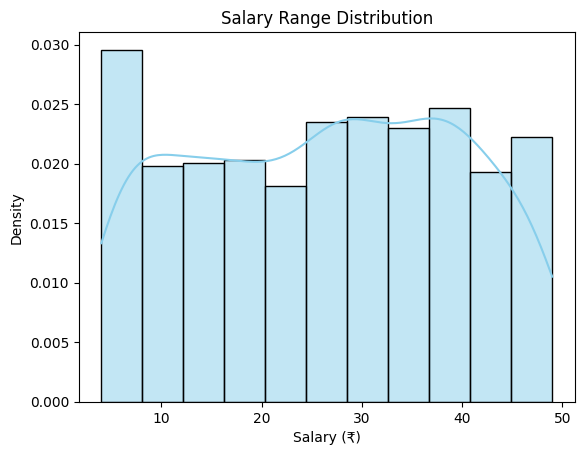

In [9]:
sns.histplot(data=df, x='salary_lpa', kde=True, color='skyblue', stat="density")

# Customization
plt.title('Salary Range Distribution')
plt.xlabel('Salary (₹)')
plt.ylabel('Density')
plt.show()

Most Common Salary Range: 30-40(LPA)

Distribution Shape: Relatively balance but shows a strong concentration in the mid-to-high range (30-45). With fewer jobs offering "entry-level" salaries(10-20) 

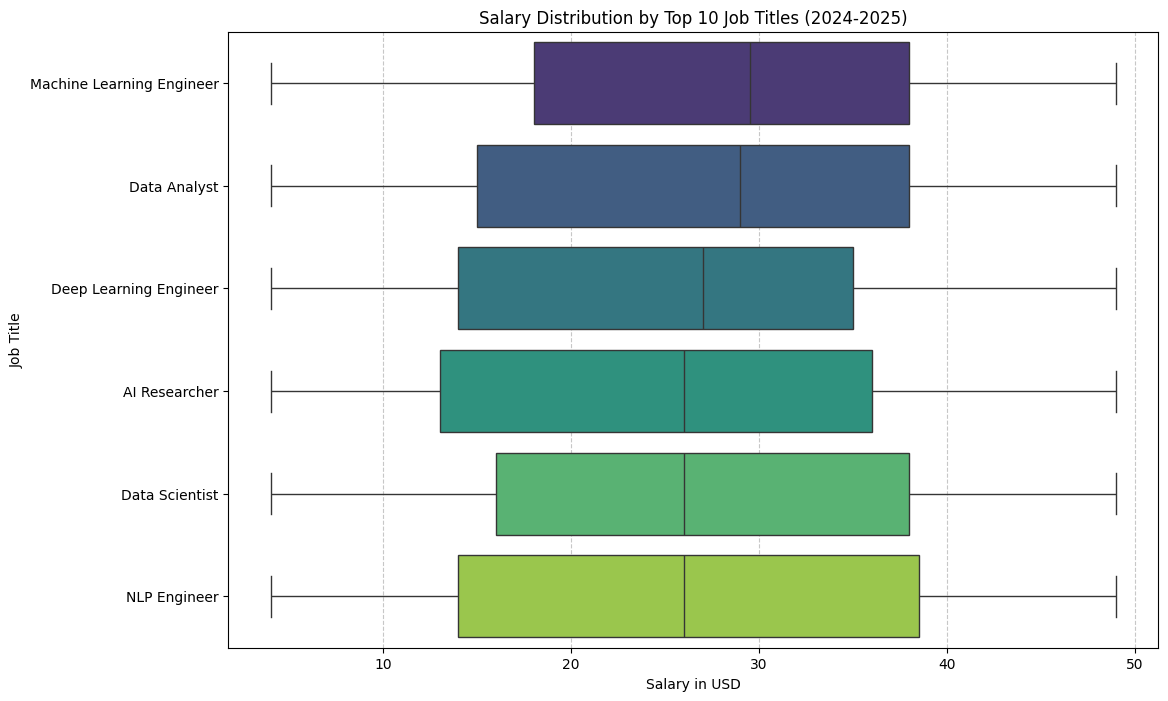

In [10]:
# 2. Filter for the top 10 most common job titles to avoid a cluttered graph

# 3. Create the distribution plot
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='salary_lpa', y='job_title', 
            palette='viridis', order=df.groupby('job_title')['salary_lpa'].median().sort_values(ascending=False).index)

plt.title('Salary Distribution by Top 10 Job Titles (2024-2025)')
plt.xlabel('Salary in USD')
plt.ylabel('Job Title')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Highest salary**: Machine Learning Engineers and Deep Learning Engineers have highest median salaries

**Salary Variation**: Data Analyst has a tall box suggesting a wide variety in pay -  some entry level may pay less than senior role.

**Competitive Mid-Range** : AI Researchers and Data Scientists shosmedian salaries

In All we can infer:

**Machine Learning Engineers** have highest salary rank
**Deep Learning Engineers** have very highest salary rank
**Data Scientist** have high salary rank
Data Analyst have very moderate salary rank

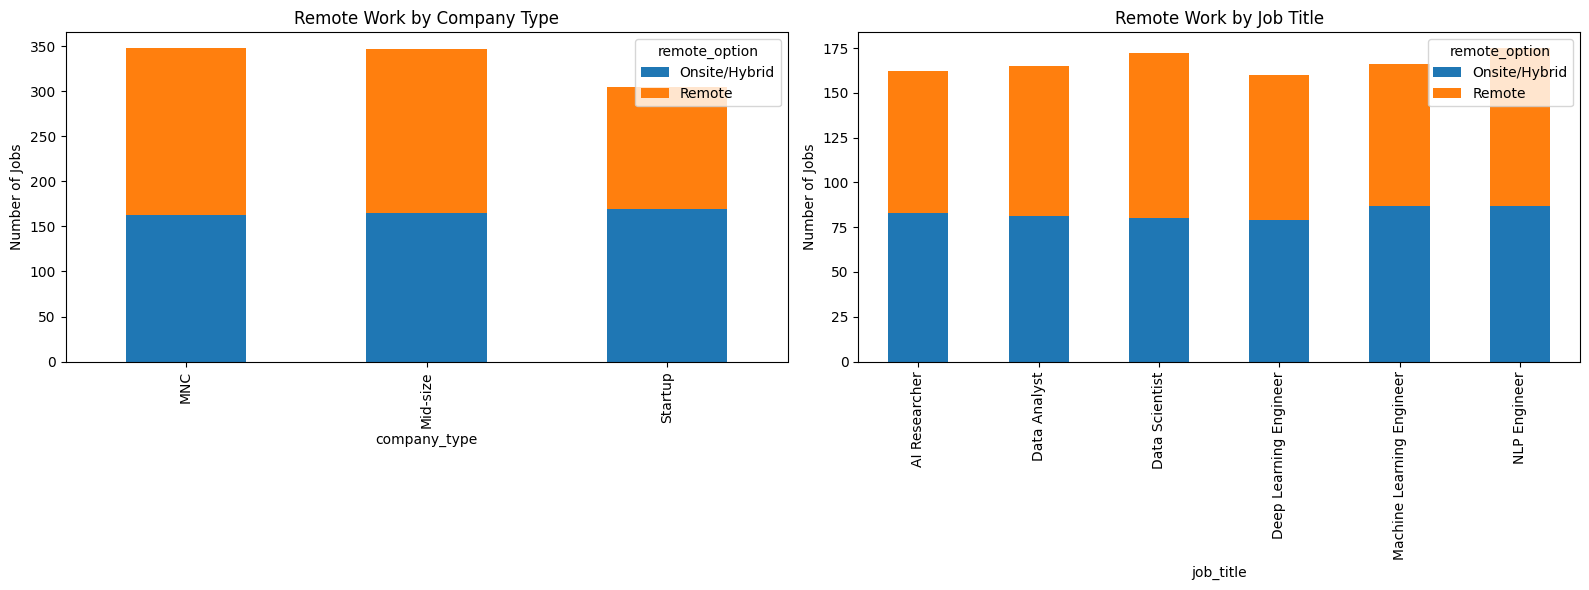

In [11]:
# 1. Prepare subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Remote Options by Company Type
ct_comp = pd.crosstab(df['company_type'], df['remote_option'])
ct_comp.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Remote Work by Company Type')
axes[0].set_ylabel('Number of Jobs')

# Plot 2: Remote Options by Job Title
# Note: If you have many titles, you may want to filter for the Top 10 first
ct_job = pd.crosstab(df['job_title'], df['remote_option'])
ct_job.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Remote Work by Job Title')
axes[1].set_ylabel('Number of Jobs')

# 2. Refine layout
plt.tight_layout()

**Remote Work by Company Type**: 

**Startups**: Offers highest number of jobs with greatest proportion of remote job

**MNC**:  Offers fewest number of jobs with greatest proportion of Onsite/Hybrid job

**Mid-size**: Falls in between with a roughly even distribution between remote and hybrid/onsite

**Remote Work by Job Title**:

Data Analyst is the most common job title while AI Researcheris the least common in terms of Remote job.

Data Scientist, Deep Learning Engineer and NLP Engineer - Onsite/Hybrid is more prevalent than fully remote positions

Data suggests that while remote is more prevalent in startups, online /hybrid remain common in larger corporates and across specific technical jobtitles

In [12]:
df.head()

,job_id,job_title,company_type,experience_level,salary_lpa,location,remote_option,skills_required,industry,posting_month
0,1,NLP Engineer,Mid-size,Junior,42,Mumbai,Remote,"Python, Statistics, Scikit-learn",EdTech,Apr
1,2,Machine Learning Engineer,MNC,Junior,32,Delhi,Remote,"Python, Statistics, Scikit-learn",EdTech,Aug
2,3,Machine Learning Engineer,Mid-size,Junior,18,Mumbai,Onsite/Hybrid,"SQL, Power BI, Excel",HealthTech,Nov
3,4,NLP Engineer,Mid-size,Junior,46,Delhi,Remote,"Python, NLP, Transformers",HealthTech,Nov
4,5,AI Researcher,Mid-size,Senior,11,Hyderabad,Onsite/Hybrid,"Python, NLP, Transformers",HealthTech,Apr


In [13]:
df['posting_month'].unique()

array(['Apr', 'Aug', 'Nov', 'May', 'Jan', 'Feb', 'Mar', 'Jun', 'Jul',
       'Oct', 'Dec', 'Sep'], dtype=object)

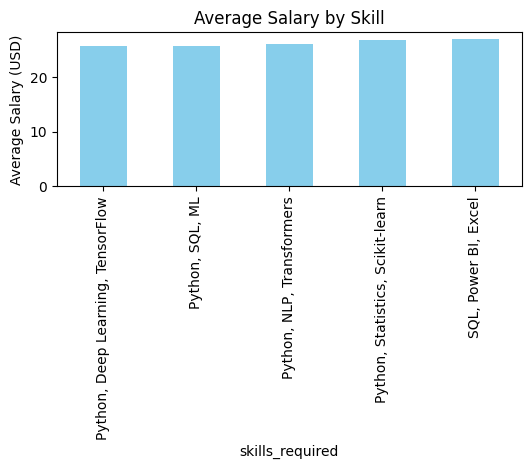

In [14]:
# Group by skill and get mean salary
mean_salary = df.groupby('skills_required')['salary_lpa'].mean().sort_values()

# Plot bar chart
mean_salary.plot(kind='bar', figsize=(6,2), color='skyblue')
plt.title('Average Salary by Skill')
plt.ylabel('Average Salary (USD)')
plt.show()

All listed skill combinations have an average salary of approximately 20,000 based on the visual representation in the graph

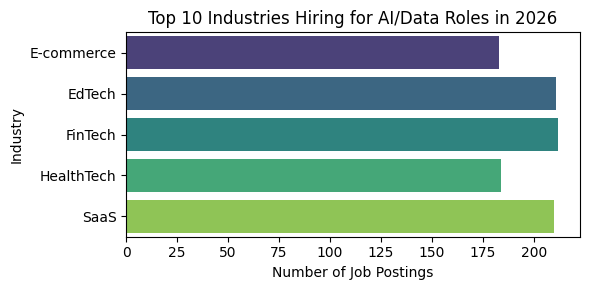

In [15]:
# Prepare data
top_industries = df['industry'].value_counts().nlargest(10)

# Plot data
plt.figure(figsize=(6,3))
sns.barplot(x=top_industries.values, y=top_industries.index, palette='viridis')
plt.title('Top 10 Industries Hiring for AI/Data Roles in 2026')
plt.xlabel('Number of Job Postings')
plt.ylabel('Industry')
plt.tight_layout()
plt.show()

FinTech and EdTech have the highest number of job posting(around 180-190 positions)
All lited industries show a high level of demand for Ai and data professionals in  2026

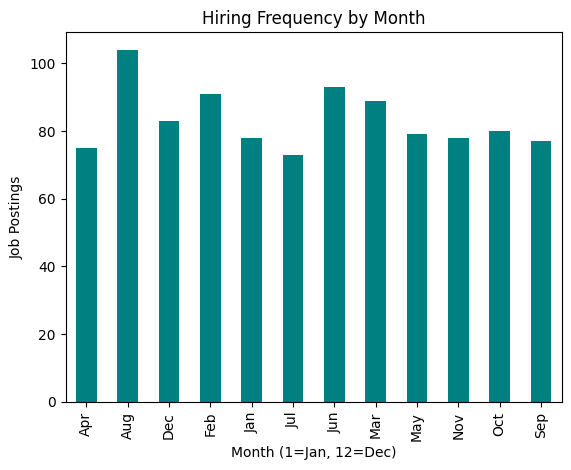

In [16]:
df['posting_month'].value_counts().sort_index().plot(kind='bar', color='teal')

plt.title("Hiring Frequency by Month")
plt.xlabel("Month (1=Jan, 12=Dec)")
plt.ylabel("Job Postings")
plt.show()

Highest Frequency: August has the highet no of job posting(100); Lowest Frequency: July has lowest job(<80)
General Trend:  Most month shows a frequency of job posting between approximately 70-90 

In [17]:
# Group by Experience Level and count the job roles (Availability)
experience_trends = df.groupby('experience_level')['job_title'].count().sort_values(ascending=False)

print("Job Availability by Experience Level:")
print(experience_trends)

Job Availability by Experience Level:
experience_level
Senior     266
Mid        259
Junior     246
Fresher    229
Name: job_title, dtype: int64


Senior level witess  more hiring comparitivey . hough other levels are not lagging much

##  Final Conclusions

* **Machine Learning Engineers and Deep Learning Engineers dominate salary rankings**
* **Startups lead in job availability and remote opportunities**
* **MNCs prefer structured onsite/hybrid roles**
* **Data Analyst roles show the highest variability in salaries**
* **FinTech and EdTech industries drive the most hiring**
* **Remote work is growing but not universal across all technical roles**
* **Overall demand for AI professionals remains strong and consistent**

---

##  Key Takeaway

The AI job market in 2026 is **highly dynamic and opportunity-rich**, with strong demand across industries, competitive salaries, and evolving work models. Candidates with specialized skills and experience in advanced AI domains are best positioned to maximize career growth.